# SOLA and PSOLA: Audio Signal Processing
This notebook demonstrates the use of **SOLA (Synchronous Overlap and Add)** and **PSOLA (Pitch Synchronous Overlap and Add)** for time-stretching and pitch-shifting audio signals. We'll visualize the results and listen to the processed audio to understand the effects.

In [49]:
import numpy as np
from scipy.signal import find_peaks
from scipy.io.wavfile import read, write

import matplotlib.pyplot as plt
from IPython.display import Audio, display

import soundfile as sf
from urllib.request import urlopen
import io


## SOLA Implementation
**SOLA (Synchronous Overlap and Add)** is used for time-stretching audio without altering its pitch.

In [50]:
def time_stretch_sola(audio, stretch_factor, window_size=2048, hop_size=512):
    """
    Apply SOLA (Synchronous Overlap and Add) for time-stretching.
    :param audio: Input audio signal (numpy array)
    :param stretch_factor: Stretching factor (>1 for slower, <1 for faster)
    :param window_size: Size of analysis window
    :param hop_size: Overlap hop size
    :return: Stretched audio signal
    """
    stretched_audio = np.zeros(int(len(audio) * stretch_factor), dtype=audio.dtype)
    window = np.hanning(window_size)
    pos_in = 0
    pos_out = 0

    while pos_out + window_size < len(stretched_audio)-window_size:
        # Read segment of input audio
        segment = audio[pos_in:pos_in + window_size] * window

        # Write to the output with overlap
        stretched_audio[pos_out:pos_out + window_size] += segment

        # Find best overlap position using cross-correlation
        if pos_out > 0:
            prev_segment = stretched_audio[pos_out - hop_size:pos_out]
            corr = np.correlate(prev_segment, segment[:hop_size], mode='valid')
            best_offset = np.argmax(corr)
            pos_in += best_offset

        pos_in += hop_size
        pos_out += int(hop_size * stretch_factor)

    return stretched_audio

## PSOLA Implementation
**PSOLA (Pitch Synchronous Overlap and Add)** is used for pitch-shifting audio without altering its duration.

In [51]:
def pitch_shift_psola(audio, sample_rate, pitch_factor):
    """
    Apply PSOLA (Pitch Synchronous Overlap and Add) for pitch-shifting.
    :param audio: Input audio signal (numpy array)
    :param sample_rate: Sampling rate of the input audio
    :param pitch_factor: Pitch factor (>1 for higher, <1 for lower)
    :return: Pitch-shifted audio signal
    """
    peaks, _ = find_peaks(audio, distance=sample_rate // 100)
    output_audio = np.zeros_like(audio)

    for i in range(1, len(peaks)):
        period = peaks[i] - peaks[i - 1]
        scaled_period = int(period * pitch_factor)

        # Resample each pitch period
        period_waveform = audio[peaks[i - 1]:peaks[i]]
        resampled_waveform = np.interp(
            np.linspace(0, len(period_waveform), scaled_period),
            np.arange(len(period_waveform)),
            period_waveform
        )

        # Write to output with overlap
        output_audio[peaks[i - 1]:peaks[i - 1] + len(resampled_waveform)] += resampled_waveform

    return output_audio

## Load and Visualize Input Audio

In [1]:
url = 'https://ringbuffer.org/download/audio/voice/local_mushrooms.wav'
audio_data, sample_rate  = sf.read(io.BytesIO(urlopen(url).read()))


if len(audio_data.shape) > 1:  # Convert stereo to mono if necessary
    audio_data = np.mean(audio_data, axis=1).astype(audio_data.dtype)

# Visualization of Original Signal
plt.figure(figsize=(12, 6))
plt.title("Original Audio Signal")
plt.plot(audio_data[:sample_rate])  # Plot first second
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()
display(Audio(audio_data, rate=sample_rate))

NameError: name 'sf' is not defined

## Apply SOLA (Time-Stretching)

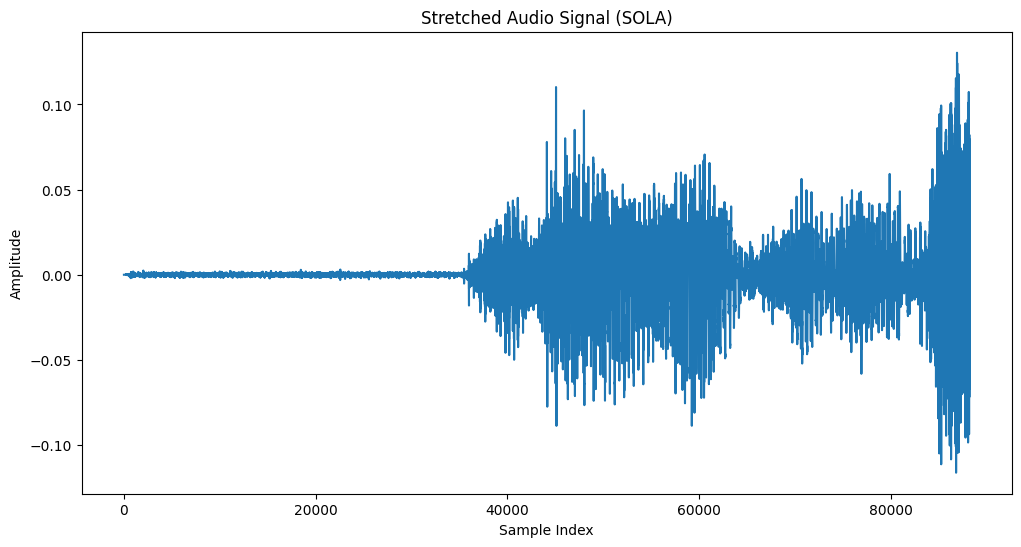

In [55]:
stretch_factor = 2  # Slow down by 50%
stretched_audio = time_stretch_sola(audio_data, stretch_factor)

# Visualization of Stretched Signal
plt.figure(figsize=(12, 6))
plt.title("Stretched Audio Signal (SOLA)")
plt.plot(stretched_audio[:int(sample_rate * stretch_factor)])  # Plot first stretched second
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()
display(Audio(stretched_audio, rate=sample_rate))

## Apply PSOLA (Pitch-Shifting)

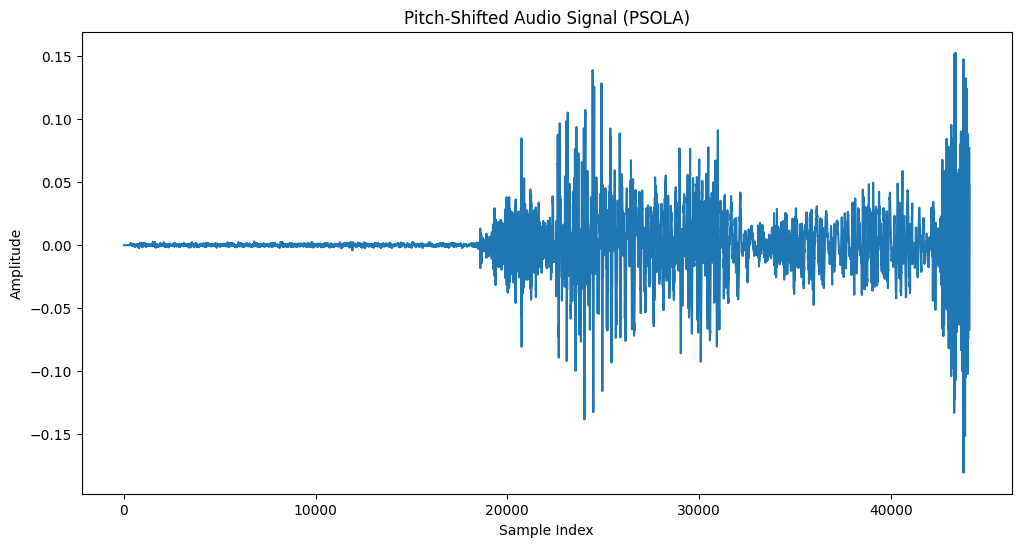

In [48]:
pitch_factor = 1.2  # Increase pitch by 20%
pitch_shifted_audio = pitch_shift_psola(audio_data, sample_rate, pitch_factor)

# Visualization of Pitch-Shifted Signal
plt.figure(figsize=(12, 6))
plt.title("Pitch-Shifted Audio Signal (PSOLA)")
plt.plot(pitch_shifted_audio[:sample_rate])  # Plot first second
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()
display(Audio(pitch_shifted_audio, rate=sample_rate))

## Summary
Using SOLA, we can stretch audio in time without changing its pitch, while PSOLA allows us to shift the pitch without altering the duration. These techniques are widely used in audio processing for applications like music production, speech synthesis, and more.